# One-Period Debt with Sunspots and LOLR

This notebook is a short and simple implementation of the model in `docs/LOLR_oneperioddebt_vsunspot.pdf`.

- State: private debt `b`, LOLR debt `l`, growth `g`, sunspot `s`, shock `eps`.
- Choice in repayment: next private debt `b'` and next LOLR debt `l'`.
- Choice in default: next LOLR debt `l'` only.

The code is intentionally compact. The bad-sunspot schedule uses a simple upper-envelope filter, which keeps the implementation readable.

In [127]:
using Statistics
include("src/simple_s_lolr.jl")
Threads.nthreads()

8

In [128]:
# Small baseline so the notebook runs quickly.
# Set LOLR borrowing to zero by collapsing the l-grid to {0}.
model = init_model(Model(Nb = 800, Nl = 20, Ne = 5, Δ_nd = 0.05, Δ_d = 0.05))
model.max_iter = 50
model.max_iter_vd = 100
model.max_iter_x = 100
model.pub = 0.65
model

Model(800, 20, 2, 2, 5, -0.05, 1.0, 0.0, 0.06, [-0.05, -0.048685857321652065, -0.04737171464330413, -0.0460575719649562, -0.04474342928660826, -0.04342928660826033, -0.04211514392991239, -0.04080100125156445, -0.03948685857321652, -0.038172715894868585  …  0.9881727158948685, 0.9894868585732165, 0.9908010012515645, 0.9921151439299124, 0.9934292866082604, 0.9947434292866083, 0.9960575719649561, 0.9973717146433041, 0.998685857321652, 1.0], [0.0, 0.003157894736842105, 0.00631578947368421, 0.009473684210526316, 0.01263157894736842, 0.015789473684210527, 0.018947368421052633, 0.022105263157894735, 0.02526315789473684, 0.028421052631578948, 0.031578947368421054, 0.034736842105263156, 0.037894736842105266, 0.04105263157894737, 0.04421052631578947, 0.04736842105263158, 0.05052631578947368, 0.05368421052631579, 0.056842105263157895, 0.06], [0.96, 1.04], [-2.5, -1.25, 0.0, 1.25, 2.5], [0.6 0.4; 0.25 0.75], [0.25 0.75; 0.25 0.75], [0.030396361765261396, 0.2355891672834392, 0.4680289419025988, 0.2

In [129]:
# Time the main steps inside solve_model.
function time_solve_steps(model; n_iter = min(1, model.max_iter))
    sol = initial_solution(model)
    l = model.l
    y = reshape(model.g, model.Ng, 1) .* exp.(model.sigma_eps .* reshape(model.eps, 1, model.Ne))
    g_beta = model.beta .* (model.g .^ (1 - model.gamma))
    gb = reshape(model.b, model.Nb, 1, 1, 1) .* reshape(model.g, 1, 1, model.Ng, 1)
    bprime_idx = nearest_index(model.b, model.b ./ reshape(model.g, 1, model.Ng))
    kbprime_idx = nearest_index(model.b, model.kappa .* model.b ./ reshape(model.g, 1, model.Ng))
    b0_idx = findmin(abs.(model.b))[2]
    l0_idx = findmin(abs.(l))[2]

    vnd = copy(sol.vnd)
    vd = copy(sol.vd)
    X = copy(sol.X)
    d = copy(sol.d)
    e = copy(sol.e)
    QE = Array{Float64}(undef, model.Nb, model.Nl, model.Ng, model.Ns)
    R = copy(sol.R)
    n = copy(sol.n)
    pdefault = copy(sol.pdefault)
    QE_tmp = Vector{Float64}(undef, model.Nb * model.Nl * model.Ng * model.Ns)
    pdefault_tmp = similar(QE_tmp)
    l_policy_idx_d = copy(sol.l_policy_idx_d)

    t_vd = 0.0
    t_default = 0.0
    t_prices = 0.0
    t_schedule = 0.0
    t_mask = 0.0
    t_vnd = 0.0

    for it in 1:n_iter
        damp = max(0.05, 0.9 - 0.0 * ((it - 1) / 10))

        t_vd += @elapsed begin
            vd_err, l_policy_idx_d = _solve_vd!(vd, vnd, model, y, g_beta, bprime_idx, kbprime_idx)
        end

        t_default += @elapsed begin
            d = vnd .< vd
            e = .!d
        end

        t_prices += @elapsed begin
            Q, x_err = _solve_prices!(X, d, e, model, bprime_idx, kbprime_idx, l_policy_idx_d)
        end

        t_schedule += @elapsed begin
            _compute_schedule!(QE, R, n, pdefault, model, Q, d, gb, QE_tmp, pdefault_tmp)
        end

        t_mask += @elapsed begin
            schedule_mask = _select_schedule_mask(n, R, pdefault, model)
        end

        t_vnd += @elapsed begin
            err = _update_vnd!(vnd, vd, model, y, g_beta, n, pdefault, schedule_mask, b0_idx, l0_idx; damp = damp)
        end

        println("iter=", it, ", vnd_err=", err, ", vd_err=", vd_err, ", x_err=", x_err)
    end

    println()
    println("Timing over ", n_iter, " outer iterations")
    println("  solve_vd:        ", round(t_vd, digits = 3), " s")
    println("  default_reentry: ", round(t_default, digits = 3), " s")
    println("  solve_prices:    ", round(t_prices, digits = 3), " s")
    println("  compute_schedule:", round(t_schedule, digits = 3), " s")
    println("  select_mask:     ", round(t_mask, digits = 3), " s")
    println("  update_vnd:      ", round(t_vnd, digits = 3), " s")
    return nothing
end

time_solve_steps(model)


iter=1, vnd_err=1.7592988383119126, vd_err=5.197516816934922e-7, x_err=9.83002089283147e-7

Timing over 1 outer iterations
  solve_vd:        0.398 s
  default_reentry: 0.001 s
  solve_prices:    2.03 s
  compute_schedule:0.006 s
  select_mask:     0.008 s
  update_vnd:      6.139 s


## Step-by-Step Diagnostics

These cells mimic the steps inside `solve_model`, one block at a time. Run them in order to see which block looks wrong before the full outer fixed point is used.

In [130]:
using Plots

function make_debug_state(model)
    sol = initial_solution(model)
    l = model.l
    y = reshape(model.g, model.Ng, 1) .* exp.(model.sigma_eps .* reshape(model.eps, 1, model.Ne))
    g_beta = model.beta .* (model.g .^ (1 - model.gamma))
    gb = reshape(model.b, model.Nb, 1, 1, 1) .* reshape(model.g, 1, 1, model.Ng, 1)
    bprime_idx = nearest_index(model.b, model.b ./ reshape(model.g, 1, model.Ng))
    kbprime_idx = nearest_index(model.b, model.kappa .* model.b ./ reshape(model.g, 1, model.Ng))
    b0_idx = findmin(abs.(model.b))[2]
    l0_idx = findmin(abs.(l))[2]
    QE = Array{Float64}(undef, model.Nb, model.Nl, model.Ng, model.Ns)
    QE_tmp = Vector{Float64}(undef, model.Nb * model.Nl * model.Ng * model.Ns)
    pdefault_tmp = similar(QE_tmp)

    return Dict{Symbol, Any}(
        :vnd => copy(sol.vnd),
        :vd => copy(sol.vd),
        :X => copy(sol.X),
        :Q => copy(sol.Q),
        :d => copy(sol.d),
        :e => copy(sol.e),
        :R => copy(sol.R),
        :n => copy(sol.n),
        :pdefault => copy(sol.pdefault),
        :schedule_mask => copy(sol.schedule_mask),
        :l_policy_idx_d => copy(sol.l_policy_idx_d),
        :QE => QE,
        :QE_tmp => QE_tmp,
        :pdefault_tmp => pdefault_tmp,
        :y => y,
        :g_beta => g_beta,
        :gb => gb,
        :bprime_idx => bprime_idx,
        :kbprime_idx => kbprime_idx,
        :b0_idx => b0_idx,
        :l0_idx => l0_idx,
    )
end

dbg = make_debug_state(model)
e_idx = cld(model.Ne, 2)
l_idx = 1
gi = 1
s_bad = 1
s_good = min(2, model.Ns)

println("Debug state ready.")
println("Use gi=", gi, ", l_idx=", l_idx, ", e_idx=", e_idx)


Debug state ready.
Use gi=1, l_idx=1, e_idx=3


vd_err = 5.197516816934922e-7


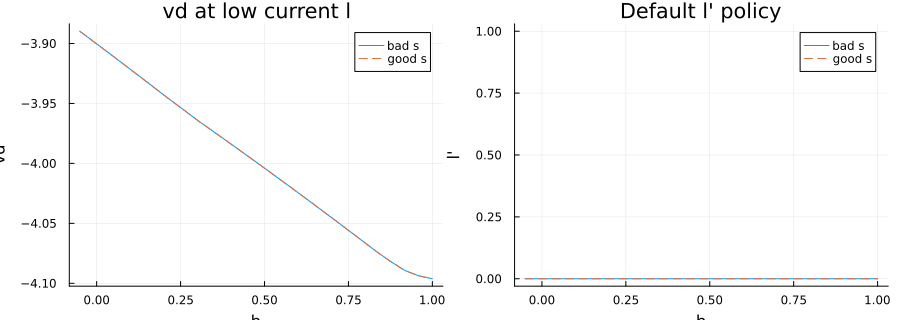

In [131]:
# Step 2: solve vd given current vnd.
vd_err, dbg[:l_policy_idx_d] = _solve_vd!(dbg[:vd], dbg[:vnd], model, dbg[:y], dbg[:g_beta], dbg[:bprime_idx], dbg[:kbprime_idx])
println("vd_err = ", vd_err)

p1 = plot(model.b, dbg[:vd][:, l_idx, gi, s_bad, e_idx], label = "bad s", xlabel = "b", ylabel = "vd", title = "vd at low current l")
plot!(p1, model.b, dbg[:vd][:, l_idx, gi, s_good, e_idx], label = "good s", linestyle = :dash)

p2 = plot(model.b, model.l[dbg[:l_policy_idx_d][:, l_idx, gi, s_bad, e_idx]], label = "bad s", xlabel = "b", ylabel = "l'", title = "Default l' policy")
plot!(p2, model.b, model.l[dbg[:l_policy_idx_d][:, l_idx, gi, s_good, e_idx]], label = "good s", linestyle = :dash)

plot(p1, p2, layout = (1, 2), size = (900, 320))


Mean default probability in grid = 0.67539375


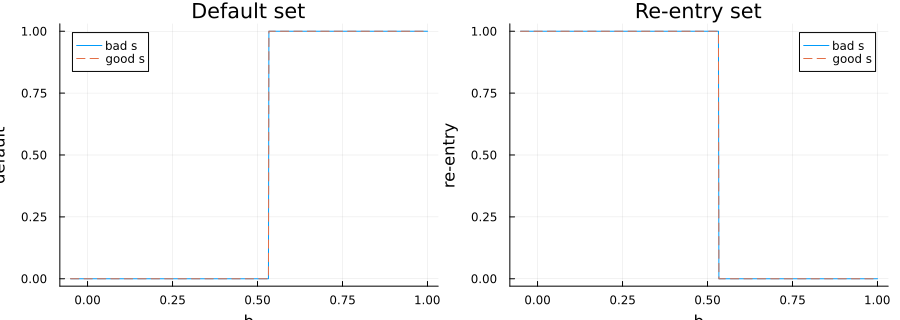

In [132]:
# Step 3: default and re-entry from vnd and vd.
dbg[:d] = dbg[:vnd] .< dbg[:vd]
dbg[:e] = .!dbg[:d]
println("Mean default probability in grid = ", mean(dbg[:d]))

p1 = plot(model.b, Float64.(dbg[:d][:, l_idx, gi, s_bad, e_idx]), label = "bad s", xlabel = "b", ylabel = "default", title = "Default set")
plot!(p1, model.b, Float64.(dbg[:d][:, l_idx, gi, s_good, e_idx]), label = "good s", linestyle = :dash)

p2 = plot(model.b, Float64.(dbg[:e][:, l_idx, gi, s_bad, e_idx]), label = "bad s", xlabel = "b", ylabel = "re-entry", title = "Re-entry set")
plot!(p2, model.b, Float64.(dbg[:e][:, l_idx, gi, s_good, e_idx]), label = "good s", linestyle = :dash)

plot(p1, p2, layout = (1, 2), size = (900, 320))


x_err = 9.83002089283147e-7


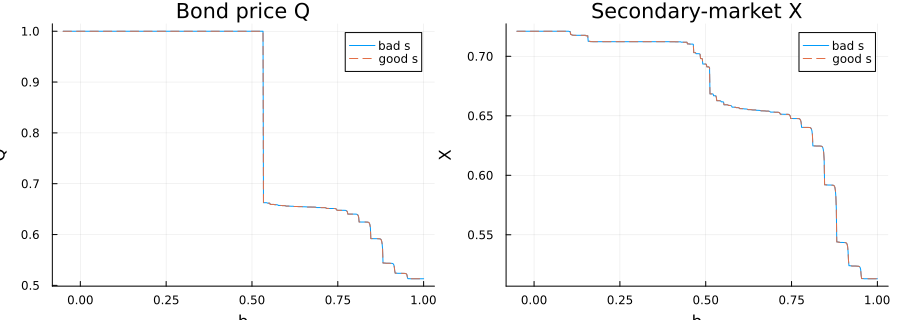

In [133]:
# Step 4: solve prices Q and X given d, e, and default l' policy.
dbg[:Q], x_err = _solve_prices!(dbg[:X], dbg[:d], dbg[:e], model, dbg[:bprime_idx], dbg[:kbprime_idx], dbg[:l_policy_idx_d])
println("x_err = ", x_err)

p1 = plot(model.b, dbg[:Q][:, l_idx, gi, s_bad, e_idx], label = "bad s", xlabel = "b", ylabel = "Q", title = "Bond price Q")
plot!(p1, model.b, dbg[:Q][:, l_idx, gi, s_good, e_idx], label = "good s", linestyle = :dash)

p2 = plot(model.b, dbg[:X][:, l_idx, gi, s_bad, e_idx], label = "bad s", xlabel = "b", ylabel = "X", title = "Secondary-market X")
plot!(p2, model.b, dbg[:X][:, l_idx, gi, s_good, e_idx], label = "good s", linestyle = :dash)

plot(p1, p2, layout = (1, 2), size = (900, 320))


Bad-sunspot available points = 15864
Good-sunspot available points = 16000


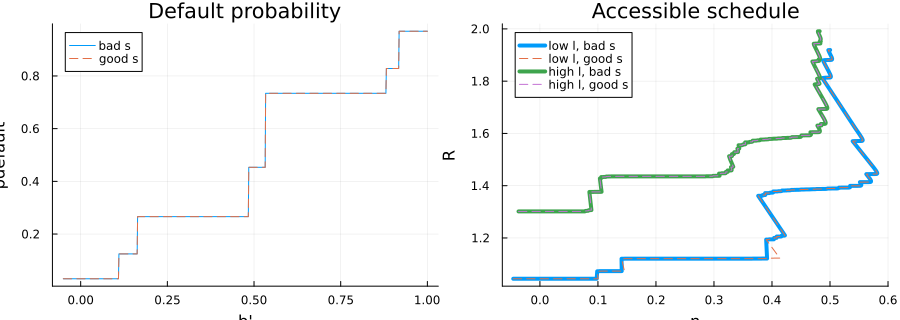

In [134]:
# Step 5: schedules and sunspot mask given Q and d.
_compute_schedule!(dbg[:QE], dbg[:R], dbg[:n], dbg[:pdefault], model, dbg[:Q], dbg[:d], dbg[:gb], dbg[:QE_tmp], dbg[:pdefault_tmp])
dbg[:schedule_mask] = _select_schedule_mask(dbg[:n], dbg[:R], dbg[:pdefault], model)

mask_bad = dbg[:schedule_mask][:, :, gi, s_bad]
mask_good = dbg[:schedule_mask][:, :, gi, s_good]
println("Bad-sunspot available points = ", count(mask_bad))
println("Good-sunspot available points = ", count(mask_good))
l_low = 1
l_high = model.Nl

function masked_line(x, y, mask)
    return x,y
end

p1 = plot(model.b, dbg[:pdefault][:, l_idx, gi, s_bad], label = "bad s", xlabel = "b'", ylabel = "pdefault", title = "Default probability")
plot!(p1, model.b, dbg[:pdefault][:, l_idx, gi, s_good], label = "good s", linestyle = :dash)

mask_bad_low = dbg[:schedule_mask][:, l_low, gi, s_bad]
mask_good_low = dbg[:schedule_mask][:, l_low, gi, s_good]
mask_bad_high = dbg[:schedule_mask][:, l_high, gi, s_bad]
mask_good_high = dbg[:schedule_mask][:, l_high, gi, s_good]

n_bad_low = dbg[:n][mask_bad_low, l_low, gi, s_bad]
R_bad_low = dbg[:R][mask_bad_low, l_low, gi, s_bad]
n_good_low = dbg[:n][mask_good_low, l_low, gi, s_good]
R_good_low = dbg[:R][mask_good_low, l_low, gi, s_good]
n_bad_high = dbg[:n][mask_bad_high, l_high, gi, s_bad]
R_bad_high = dbg[:R][mask_bad_high, l_high, gi, s_bad]
n_good_high = dbg[:n][mask_good_high, l_high, gi, s_good]
R_good_high = dbg[:R][mask_good_high, l_high, gi, s_good]

p2 = plot(n_bad_low, R_bad_low, label = "low l, bad s", xlabel = "n", ylabel = "R", title = "Accessible schedule", linewidth = 4)
plot!(p2, n_good_low, R_good_low, label = "low l, good s", linestyle = :dash, linewidth = 1)
plot!(p2, n_bad_high, R_bad_high, label = "high l, bad s", linewidth = 4)
plot!(p2, n_good_high, R_good_high, label = "high l, good s", linestyle = :dash, linewidth = 1)

plot(p1, p2, layout = (1, 2), size = (900, 320))


Final vnd_err = 1.7592988383119126


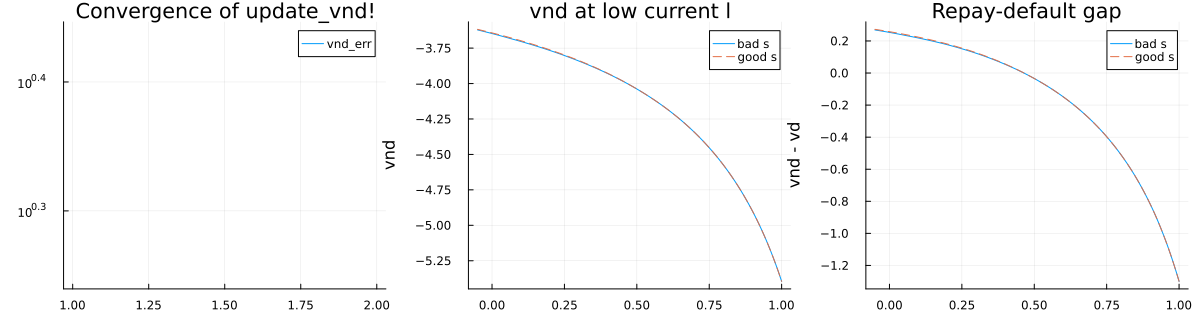

In [135]:
# Step 6: update vnd given the current schedules, jusdt one iteration to check the error and convergence. The full iteration is done in time_solve_steps.
vnd_errs = Float64[]
for it in 1:1
    err = _update_vnd!(dbg[:vnd], dbg[:vd], model, dbg[:y], dbg[:g_beta], dbg[:n], dbg[:pdefault], dbg[:schedule_mask], dbg[:b0_idx], dbg[:l0_idx]; damp = 0.9)
    push!(vnd_errs, err)
    err < model.tol && break
end
println("Final vnd_err = ", last(vnd_errs))

p1 = plot(vnd_errs, yscale = :log10, xlabel = "step-6 iteration", ylabel = "error", label = "vnd_err", title = "Convergence of update_vnd!")

p2 = plot(model.b, dbg[:vnd][:, l_idx, gi, s_bad, e_idx], label = "bad s", xlabel = "b", ylabel = "vnd", title = "vnd at low current l")
plot!(p2, model.b, dbg[:vnd][:, l_idx, gi, s_good, e_idx], label = "good s", linestyle = :dash)

p3 = plot(model.b, dbg[:vnd][:, l_idx, gi, s_bad, e_idx] .- dbg[:vd][:, l_idx, gi, s_bad, e_idx], label = "bad s", xlabel = "b", ylabel = "vnd - vd", title = "Repay-default gap")
plot!(p3, model.b, dbg[:vnd][:, l_idx, gi, s_good, e_idx] .- dbg[:vd][:, l_idx, gi, s_good, e_idx], label = "good s", linestyle = :dash)

plot(p1, p2, p3, layout = (1, 3), size = (1200, 320))


In [136]:
sol = solve_model(model; verbose = true)
println("Mean default probability in the state grid = ", mean(sol.d))
println("Final outer error = ", sol.outer_errs[end])

iter=1, vnd_err=1.7592988383119126, vd_err=5.197516816934922e-7, x_err=9.83002089283147e-7, damp=0.9
iter=2, vnd_err=2.0875808451906703, vd_err=9.571572325839384e-7, x_err=0.00020173185331107124, damp=0.9
iter=3, vnd_err=0.6931598835368158, vd_err=8.372142188406428e-7, x_err=1.5411654807367947e-5, damp=0.9
iter=4, vnd_err=0.26696732318273675, vd_err=7.260658341223802e-7, x_err=1.8327529375014584e-5, damp=0.9
iter=5, vnd_err=0.2827657115609288, vd_err=9.169686867593896e-7, x_err=1.6028446824689624e-5, damp=0.9
iter=6, vnd_err=0.2078637460842918, vd_err=8.683563024192154e-7, x_err=1.2638734384368133e-5, damp=0.9
iter=7, vnd_err=0.1782181213940346, vd_err=9.859222309671622e-7, x_err=1.2028522035856248e-5, damp=0.9
iter=8, vnd_err=0.14398197706311766, vd_err=9.114645491692386e-7, x_err=9.012376714911952e-6, damp=0.9
iter=9, vnd_err=0.08894026286132917, vd_err=8.248457543658105e-7, x_err=7.66706300606157e-6, damp=0.9
iter=10, vnd_err=0.07888346901274268, vd_err=9.29153065598598e-7, x_err=6.

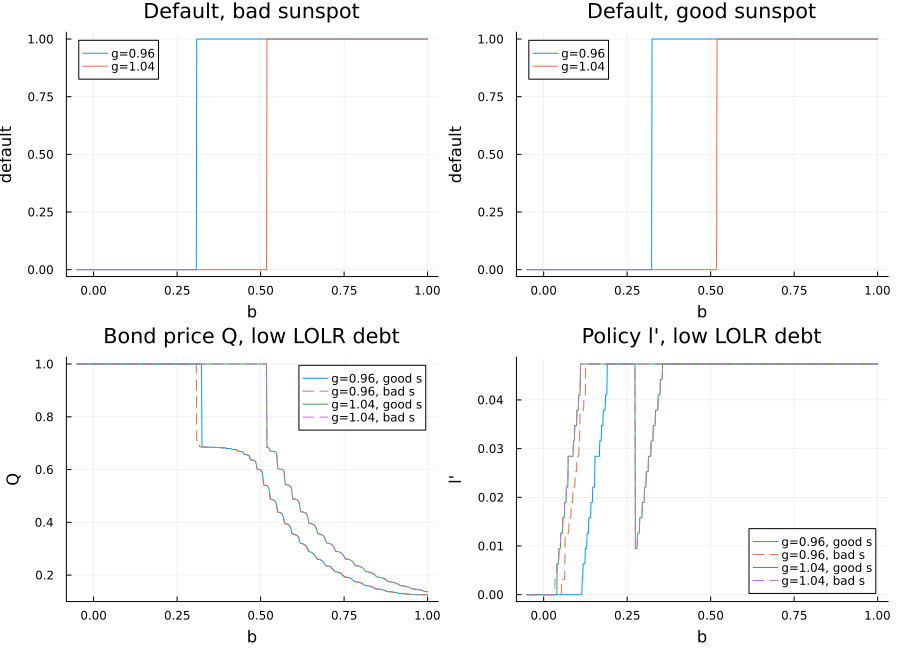

In [137]:
using Plots

b = model.b
l = model.l
g = model.g
e_idx = cld(model.Ne, 2)
l_idx = 1
s_bad = 1
s_good = 2

p1 = plot(title = "Default, bad sunspot", xlabel = "b", ylabel = "default")
p2 = plot(title = "Default, good sunspot", xlabel = "b", ylabel = "default")
p3 = plot(title = "Bond price Q, low LOLR debt", xlabel = "b", ylabel = "Q")
p4 = plot(title = "Policy l', low LOLR debt", xlabel = "b", ylabel = "l'")

for gi in 1:model.Ng
    plot!(p1, b, Float64.(sol.d[:, l_idx, gi, s_bad, e_idx]), label = "g=$(g[gi])")
    plot!(p2, b, Float64.(sol.d[:, l_idx, gi, s_good, e_idx]), label = "g=$(g[gi])")
    plot!(p3, b, sol.Q[:, l_idx, gi, s_good, e_idx], label = "g=$(g[gi]), good s")
    plot!(p3, b, sol.Q[:, l_idx, gi, s_bad, e_idx], linestyle = :dash, label = "g=$(g[gi]), bad s")
    plot!(p4, b, l[sol.l_policy_idx[:, l_idx, gi, s_good, e_idx]], label = "g=$(g[gi]), good s")
    plot!(p4, b, l[sol.l_policy_idx[:, l_idx, gi, s_bad, e_idx]], linestyle = :dash, label = "g=$(g[gi]), bad s")
end

plot(p1, p2, p3, p4, layout = (2, 2), size = (900, 650))

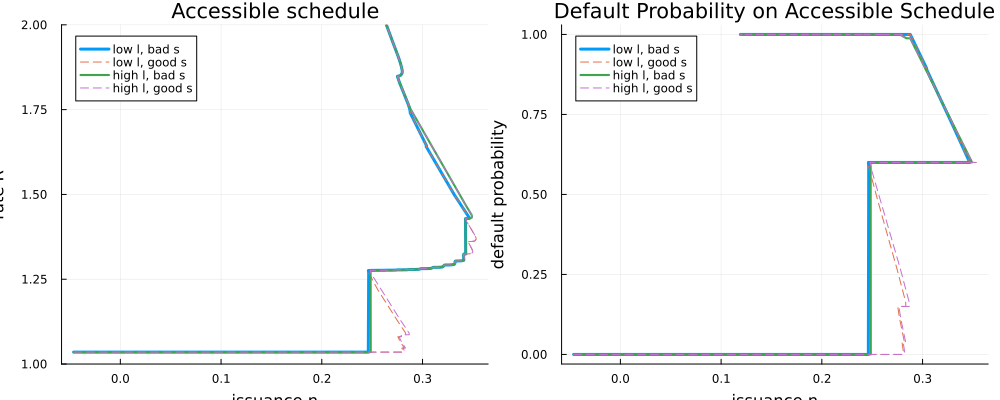

In [138]:
# Compare the available schedule lines for low and high l'.
gi = 1
l_low = 1
l_high = 10

mask_bad_low = sol.schedule_mask[:, l_low, gi, s_bad]
mask_good_low = sol.schedule_mask[:, l_low, gi, s_good]
mask_bad_high = sol.schedule_mask[:, l_high, gi, s_bad]
mask_good_high = sol.schedule_mask[:, l_high, gi, s_good]

n_bad_low = sol.n[mask_bad_low, l_low, gi, s_bad]
R_bad_low = sol.R[mask_bad_low, l_low, gi, s_bad]
n_good_low = sol.n[mask_good_low, l_low, gi, s_good]
R_good_low = sol.R[mask_good_low, l_low, gi, s_good]
n_bad_high = sol.n[mask_bad_high, l_high, gi, s_bad]
R_bad_high = sol.R[mask_bad_high, l_high, gi, s_bad]
n_good_high = sol.n[mask_good_high, l_high, gi, s_good]
R_good_high = sol.R[mask_good_high, l_high, gi, s_good]

n_bad_low_pd = sol.n[mask_bad_low, l_low, gi, s_bad]
p_bad_low = sol.pdefault[mask_bad_low, l_low, gi, s_bad]
n_good_low_pd = sol.n[mask_good_low, l_low, gi, s_good]
p_good_low = sol.pdefault[mask_good_low, l_low, gi, s_good]
n_bad_high_pd = sol.n[mask_bad_high, l_high, gi, s_bad]
p_bad_high = sol.pdefault[mask_bad_high, l_high, gi, s_bad]
n_good_high_pd = sol.n[mask_good_high, l_high, gi, s_good]
p_good_high = sol.pdefault[mask_good_high, l_high, gi, s_good]

p_sched = plot(n_bad_low, R_bad_low, label = "low l, bad s", xlabel = "issuance n", ylabel = "rate R", title = "Accessible schedule", linewidth = 3,ylims=(1.0, 2.0))
plot!(p_sched, n_good_low, R_good_low, label = "low l, good s", linestyle = :dash, linewidth = 1)
plot!(p_sched, n_bad_high, R_bad_high, label = "high l, bad s", linewidth = 2.1)
plot!(p_sched, n_good_high, R_good_high, label = "high l, good s", linestyle = :dash, linewidth = 1)

p_def = plot(n_bad_low_pd, p_bad_low, label = "low l, bad s", xlabel = "issuance n", ylabel = "default probability", title = "Default Probability on Accessible Schedule", linewidth = 3)
plot!(p_def, n_good_low_pd, p_good_low, label = "low l, good s", linestyle = :dash, linewidth = 1)
plot!(p_def, n_bad_high_pd, p_bad_high, label = "high l, bad s", linewidth = 2.1)
plot!(p_def, n_good_high_pd, p_good_high, label = "high l, good s", linestyle = :dash, linewidth = 1)

plot(p_sched, p_def, layout = (1, 2), size = (1000, 400))

## Comparative Statics: LOLR Quantity and LOLR Spread

These cells sweep a common LOLR quantity limit `Δ_nd = Δ_d = Δ` over `0.01, 0.02, 0.03, 0.04, 0.05` and set the LOLR gross rate to `R_l = 1 + r^* + σ` for `σ \in \{0.04, 0.06, 0.08, 0.10\}`.

The computation is separated from the plotting cells so the model grid only needs to be solved once.

In [139]:
delta_grid = [0.01, 0.05, 0.10, 0.15, 0.20]
sigma_grid = [0.04, 0.06, 0.08, 0.10]

# Use a smaller baseline than the detailed diagnostics so the sweep remains tractable.
grid_base_model = init_model(Model(Nb = 800, Nl = 20, Ne = 5))
grid_base_model.max_iter = 50
grid_base_model.max_iter_vd = 100
grid_base_model.max_iter_x = 100
grid_base_model.pub = 0.65

function make_grid_model(base_model, Δ, σ)
    return init_model(Model(
        Nb = base_model.Nb,
        Nl = base_model.Nl,
        Ne = base_model.Ne,
        b_min = base_model.b_min,
        b_max = base_model.b_max,
        l_min = base_model.l_min,
        l_max = base_model.l_max,
        g = copy(base_model.g),
        P_g = copy(base_model.P_g),
        P_s = copy(base_model.P_s),
        beta = base_model.beta,
        gamma = base_model.gamma,
        sigma_eps = base_model.sigma_eps,
        n_std = base_model.n_std,
        rstar = base_model.rstar,
        theta = base_model.theta,
        kappa = base_model.kappa,
        phi_g = copy(base_model.phi_g),
        nbar_g = copy(base_model.nbar_g),
        R_l_nd = 1 + base_model.rstar + σ,
        R_l_d = 1 + base_model.rstar + σ,
        Δ_nd = Δ,
        Δ_d = Δ,
        pub = base_model.pub,
        max_iter = base_model.max_iter,
        max_iter_vd = base_model.max_iter_vd,
        max_iter_x = base_model.max_iter_x,
        tol = base_model.tol,
        tol_vd = base_model.tol_vd,
        tol_x = base_model.tol_x,
    ))
end

function summarize_grid_solution(model, sol)
    s_bad = 1
    bad_mask = sol.schedule_mask[:, :, :, s_bad]
    R_bad = sol.R[:, :, :, s_bad][bad_mask]
    p_bad = sol.pdefault[:, :, :, s_bad][bad_mask]
    return (
        default_share = mean(sol.d),
        mean_l_repay = mean(model.l[sol.l_policy_idx]),
        mean_l_default = mean(model.l[sol.l_policy_idx_d]),
        mean_R_bad = isempty(R_bad) ? NaN : mean(R_bad),
        mean_p_bad = isempty(p_bad) ? NaN : mean(p_bad),
        max_l = maximum(model.l),
    )
end

function metric_matrix(summary_grid, key)
    return [getfield(summary_grid[i, j], key) for i in axes(summary_grid, 1), j in axes(summary_grid, 2)]
end

(delta_grid = delta_grid, sigma_grid = sigma_grid, grid_base_model = grid_base_model)


(delta_grid = [0.01, 0.05, 0.1, 0.15, 0.2], sigma_grid = [0.04, 0.06, 0.08, 0.1], grid_base_model = Model(800, 20, 2, 2, 5, -0.05, 1.0, 0.0, 0.06, [-0.05, -0.048685857321652065, -0.04737171464330413, -0.0460575719649562, -0.04474342928660826, -0.04342928660826033, -0.04211514392991239, -0.04080100125156445, -0.03948685857321652, -0.038172715894868585  …  0.9881727158948685, 0.9894868585732165, 0.9908010012515645, 0.9921151439299124, 0.9934292866082604, 0.9947434292866083, 0.9960575719649561, 0.9973717146433041, 0.998685857321652, 1.0], [0.0, 0.003157894736842105, 0.00631578947368421, 0.009473684210526316, 0.01263157894736842, 0.015789473684210527, 0.018947368421052633, 0.022105263157894735, 0.02526315789473684, 0.028421052631578948, 0.031578947368421054, 0.034736842105263156, 0.037894736842105266, 0.04105263157894737, 0.04421052631578947, 0.04736842105263158, 0.05052631578947368, 0.05368421052631579, 0.056842105263157895, 0.06], [0.96, 1.04], [-2.5, -1.25, 0.0, 1.25, 2.5], [0.6 0.4; 0.

In [140]:
## load
# using Serialization

# grid_results_path = joinpath("result", "grid_results_delta_sigma.jls")
# grid_results = deserialize(grid_results_path)
# grid_results


In [141]:
grid_models = Matrix{Any}(undef, length(delta_grid), length(sigma_grid))
grid_solutions = Matrix{Any}(undef, length(delta_grid), length(sigma_grid))
grid_summary = Matrix{Any}(undef, length(delta_grid), length(sigma_grid))

for (j, σ) in enumerate(sigma_grid)
    warm_sol = nothing
    for (i, Δ) in enumerate(delta_grid)
        m = make_grid_model(grid_base_model, Δ, σ)

        old_sol = if @isdefined(grid_results) &&
                    ((hasproperty(grid_results, :solutions) && grid_results.solutions[i, j] !== nothing) ||
                     (hasproperty(grid_results, :grid_solutions) && grid_results.grid_solutions[i, j] !== nothing))
            hasproperty(grid_results, :solutions) ? grid_results.solutions[i, j] : grid_results.grid_solutions[i, j]
        else
            nothing
        end

        sol_Δσ = solve_model(m; sol = warm_sol, verbose = false)
        grid_models[i, j] = m
        grid_solutions[i, j] = sol_Δσ
        grid_summary[i, j] = summarize_grid_solution(m, sol_Δσ)
        warm_sol = sol_Δσ
        println("solved Δ=", Δ, ", σ=", σ,
            ", default_share=", round(grid_summary[i, j].default_share, digits = 4),
            ", mean_l'=", round(grid_summary[i, j].mean_l_repay, digits = 4))
    end
end

grid_results = (
    delta_grid = delta_grid,
    sigma_grid = sigma_grid,
    models = grid_models,
    solutions = grid_solutions,
    summary = grid_summary,
)

[merge((Δ = delta_grid[i], σ = sigma_grid[j]), grid_summary[i, j]) for i in eachindex(delta_grid), j in eachindex(sigma_grid)]


solved Δ=0.01, σ=0.04, default_share=0.5456, mean_l'=0.0082
solved Δ=0.05, σ=0.04, default_share=0.5507, mean_l'=0.0414
solved Δ=0.1, σ=0.04, default_share=0.5558, mean_l'=0.0896
solved Δ=0.15, σ=0.04, default_share=0.5592, mean_l'=0.136
solved Δ=0.2, σ=0.04, default_share=0.5638, mean_l'=0.1826
solved Δ=0.01, σ=0.06, default_share=0.5456, mean_l'=0.008
solved Δ=0.05, σ=0.06, default_share=0.5509, mean_l'=0.0404
solved Δ=0.1, σ=0.06, default_share=0.5554, mean_l'=0.0882
solved Δ=0.15, σ=0.06, default_share=0.5592, mean_l'=0.1342
solved Δ=0.2, σ=0.06, default_share=0.5637, mean_l'=0.1806
solved Δ=0.01, σ=0.08, default_share=0.5456, mean_l'=0.0079
solved Δ=0.05, σ=0.08, default_share=0.551, mean_l'=0.0395
solved Δ=0.1, σ=0.08, default_share=0.5554, mean_l'=0.0867
solved Δ=0.15, σ=0.08, default_share=0.5592, mean_l'=0.1323
solved Δ=0.2, σ=0.08, default_share=0.5635, mean_l'=0.1783
solved Δ=0.01, σ=0.1, default_share=0.5457, mean_l'=0.0077
solved Δ=0.05, σ=0.1, default_share=0.551, mean_l'

5×4 Matrix{NamedTuple{(:Δ, :σ, :default_share, :mean_l_repay, :mean_l_default, :mean_R_bad, :mean_p_bad, :max_l), NTuple{8, Float64}}}:
 (Δ = 0.01, σ = 0.04, default_share = 0.5456, mean_l_repay = 0.00817399, mean_l_default = 0.00947368, mean_R_bad = 2.80849, mean_p_bad = 0.548369, max_l = 0.06)   …  (Δ = 0.01, σ = 0.1, default_share = 0.545722, mean_l_repay = 0.00765378, mean_l_default = 0.00945624, mean_R_bad = 2.80825, mean_p_bad = 0.548314, max_l = 0.06)
 (Δ = 0.05, σ = 0.04, default_share = 0.550737, mean_l_repay = 0.0413892, mean_l_default = 0.047312, mean_R_bad = 2.80542, mean_p_bad = 0.553797, max_l = 0.06)       (Δ = 0.05, σ = 0.1, default_share = 0.550997, mean_l_repay = 0.0384054, mean_l_default = 0.0469939, mean_R_bad = 2.80507, mean_p_bad = 0.553818, max_l = 0.06)
 (Δ = 0.1, σ = 0.04, default_share = 0.555803, mean_l_repay = 0.0896223, mean_l_default = 0.10015, mean_R_bad = 2.80816, mean_p_bad = 0.559429, max_l = 0.100923)     (Δ = 0.1, σ = 0.1, default_share = 0.555134, m

In [142]:
## save
using Serialization

grid_results_path = joinpath("result", "grid_results_delta_sigma.jls")
mkpath(dirname(grid_results_path))
serialize(grid_results_path, grid_results)
grid_results_path


"result/grid_results_delta_sigma.jls"

In [143]:
## load
# using Serialization

# grid_results_path = joinpath("result", "grid_results_delta_sigma.jls")
# grid_results = deserialize(grid_results_path)
# grid_results


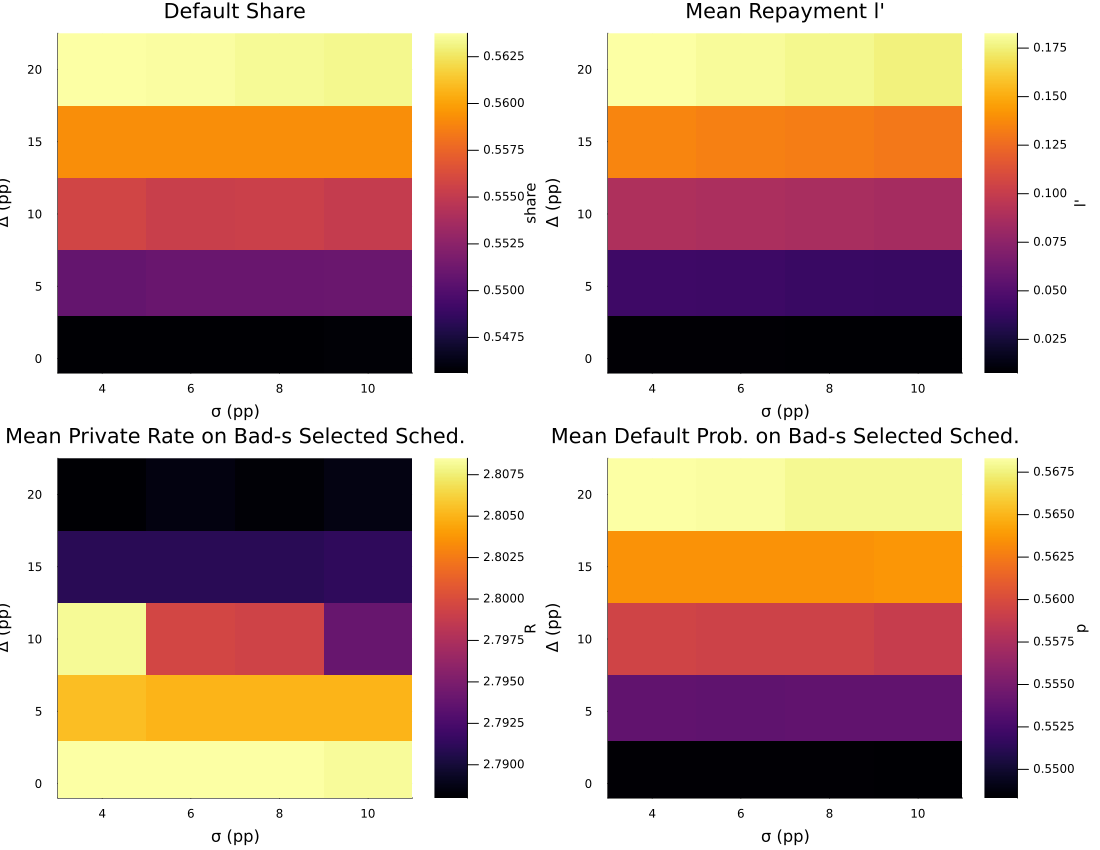

In [144]:
default_share_mat = metric_matrix(grid_results.summary, :default_share)
mean_l_repay_mat = metric_matrix(grid_results.summary, :mean_l_repay)
mean_R_bad_mat = metric_matrix(grid_results.summary, :mean_R_bad)
mean_p_bad_mat = metric_matrix(grid_results.summary, :mean_p_bad)

x_sigma = 100 .* grid_results.sigma_grid
y_delta = 100 .* grid_results.delta_grid

p1 = heatmap(x_sigma, y_delta, default_share_mat, xlabel = "σ (pp)", ylabel = "Δ (pp)", title = "Default Share", colorbar_title = "share")
p2 = heatmap(x_sigma, y_delta, mean_l_repay_mat, xlabel = "σ (pp)", ylabel = "Δ (pp)", title = "Mean Repayment l'", colorbar_title = "l'")
p3 = heatmap(x_sigma, y_delta, mean_R_bad_mat, xlabel = "σ (pp)", ylabel = "Δ (pp)", title = "Mean Private Rate on Bad-s Selected Sched.", colorbar_title = "R")
p4 = heatmap(x_sigma, y_delta, mean_p_bad_mat, xlabel = "σ (pp)", ylabel = "Δ (pp)", title = "Mean Default Prob. on Bad-s Selected Sched.", colorbar_title = "p")

plot(p1, p2, p3, p4, layout = (2, 2), size = (1100, 850))


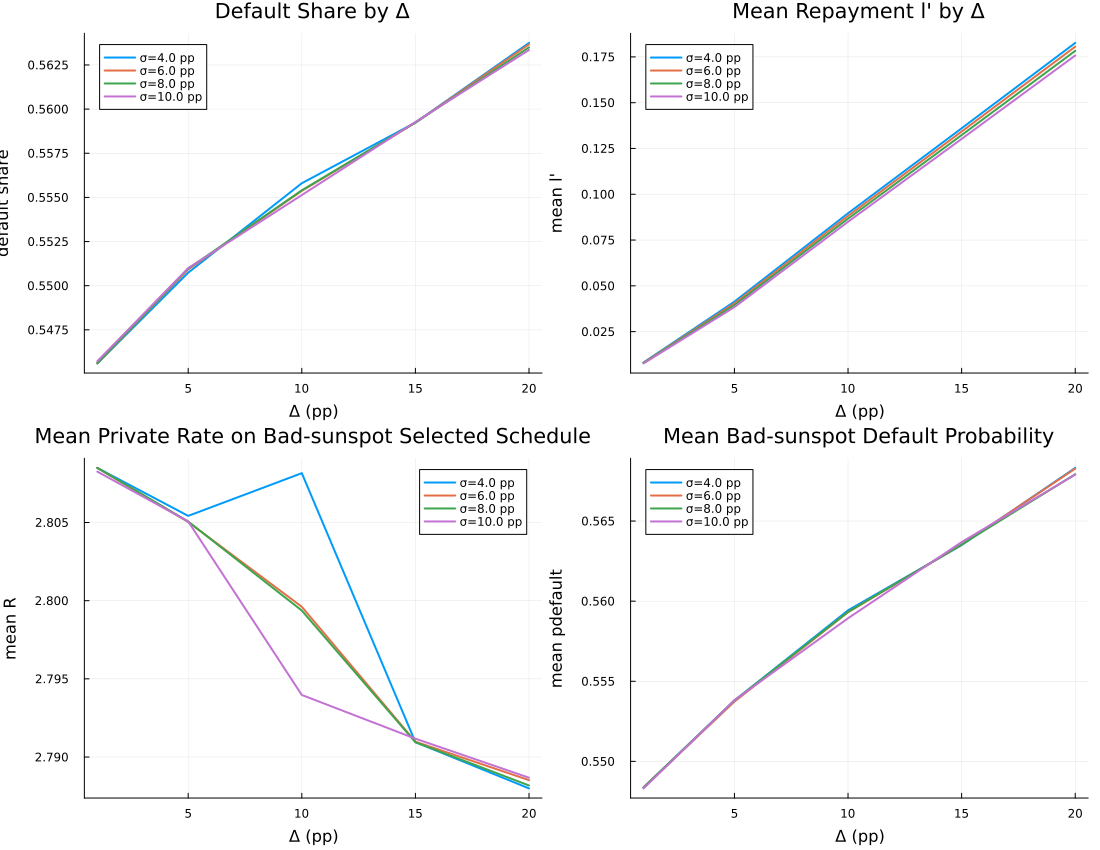

In [145]:
x_delta = 100 .* grid_results.delta_grid

p1 = plot(xlabel = "Δ (pp)", ylabel = "default share", title = "Default Share by Δ")
for (j, σ) in enumerate(grid_results.sigma_grid)
    plot!(p1, x_delta, [grid_results.summary[i, j].default_share for i in eachindex(grid_results.delta_grid)], label = "σ=$(round(100 * σ, digits = 0)) pp", lw = 2)
end

p2 = plot(xlabel = "Δ (pp)", ylabel = "mean l'", title = "Mean Repayment l' by Δ")
for (j, σ) in enumerate(grid_results.sigma_grid)
    plot!(p2, x_delta, [grid_results.summary[i, j].mean_l_repay for i in eachindex(grid_results.delta_grid)], label = "σ=$(round(100 * σ, digits = 0)) pp", lw = 2)
end

p3 = plot(xlabel = "Δ (pp)", ylabel = "mean R", title = "Mean Private Rate on Bad-sunspot Selected Schedule")
for (j, σ) in enumerate(grid_results.sigma_grid)
    plot!(p3, x_delta, [grid_results.summary[i, j].mean_R_bad for i in eachindex(grid_results.delta_grid)], label = "σ=$(round(100 * σ, digits = 0)) pp", lw = 2)
end

p4 = plot(xlabel = "Δ (pp)", ylabel = "mean pdefault", title = "Mean Bad-sunspot Default Probability")
for (j, σ) in enumerate(grid_results.sigma_grid)
    plot!(p4, x_delta, [grid_results.summary[i, j].mean_p_bad for i in eachindex(grid_results.delta_grid)], label = "σ=$(round(100 * σ, digits = 0)) pp", lw = 2)
end

plot(p1, p2, p3, p4, layout = (2, 2), size = (1100, 850))


## Moments table by LOLR regime

Compute the simulation moments used in the paper-style comparison table, reusing `grid_results` for the LOLR cases and solving only the no-LOLR baselines.


In [187]:
using Printf

function make_no_lolr_model(base_model, pb)
    return init_model(Model(
        Nb = base_model.Nb,
        Nl = 1,
        Ne = base_model.Ne,
        b_min = base_model.b_min,
        b_max = base_model.b_max,
        l_min = 0.0,
        l_max = 0.0,
        g = copy(base_model.g),
        P_g = copy(base_model.P_g),
        P_s = [pb 1 - pb; pb 1 - pb],
        beta = base_model.beta,
        gamma = base_model.gamma,
        sigma_eps = base_model.sigma_eps,
        n_std = base_model.n_std,
        rstar = base_model.rstar,
        theta = base_model.theta,
        kappa = base_model.kappa,
        phi_g = copy(base_model.phi_g),
        nbar_g = copy(base_model.nbar_g),
        R_l_nd = 1 + base_model.rstar,
        R_l_d = 1 + base_model.rstar,
        Δ_nd = 0.0,
        Δ_d = 0.0,
        pub = base_model.pub,
        max_iter = base_model.max_iter,
        max_iter_vd = base_model.max_iter_vd,
        max_iter_x = base_model.max_iter_x,
        tol = base_model.tol,
        tol_vd = base_model.tol_vd,
        tol_x = base_model.tol_x,
    ))
end

function find_grid_case_indices(grid_results, Δ, σ)
    i = findfirst(x -> isapprox(x, Δ; atol = 1e-12), grid_results.delta_grid)
    j = findfirst(x -> isapprox(x, σ; atol = 1e-12), grid_results.sigma_grid)
    @assert i !== nothing "Δ=$(Δ) not found in grid_results"
    @assert j !== nothing "σ=$(σ) not found in grid_results"
    return i, j
end

function simulate_case_moments(model, sol; T::Int, burnin::Int, seed::Int)
    b0_idx = findmin(abs.(model.b))[2]
    l0_idx = findmin(abs.(model.l))[2]
    sim = simulate(model, sol; T = T, b0_idx = b0_idx, l0_idx = l0_idx, seed = seed)
    return summarize_simulation(sim, model; sol = sol, burnin = burnin, nbins = 100)
end

lolr_table_case_specs = [
    (key = :no_lolr_pb1, group_label = "No LOLR", sub_label = "P_b = 1%", source = :no_lolr, pb = 0.01, Δ = 0.0, σ = 0.0),
    (key = :no_lolr_pb25, group_label = "No LOLR", sub_label = "P_b = 25%", source = :no_lolr, pb = 0.25, Δ = 0.0, σ = 0.0),
    (key = :delta1_sigma4, group_label = "Δ = 1%, P_b = 25%", sub_label = "σ = 4%", source = :grid, pb = 0.25, Δ = 0.01, σ = 0.04),
    (key = :delta1_sigma8, group_label = "Δ = 1%, P_b = 25%", sub_label = "σ = 8%", source = :grid, pb = 0.25, Δ = 0.01, σ = 0.08),
    (key = :delta5_sigma4, group_label = "Δ = 5%, P_b = 25%", sub_label = "σ = 4%", source = :grid, pb = 0.25, Δ = 0.05, σ = 0.04),
    (key = :delta5_sigma8, group_label = "Δ = 5%, P_b = 25%", sub_label = "σ = 8%", source = :grid, pb = 0.25, Δ = 0.05, σ = 0.08),
    (key = :delta2_sigma4, group_label = "Δ = 10%, P_b = 25%", sub_label = "σ = 4%", source = :grid, pb = 0.25, Δ = 0.10, σ = 0.04),
    (key = :delta2_sigma8, group_label = "Δ = 10%, P_b = 25%", sub_label = "σ = 8%", source = :grid, pb = 0.25, Δ = 0.10, σ = 0.08),
    (key = :delta4_sigma4, group_label = "Δ = 20%, P_b = 25%", sub_label = "σ = 4%", source = :grid, pb = 0.25, Δ = 0.20, σ = 0.04),
    (key = :delta4_sigma8, group_label = "Δ = 20%, P_b = 25%", sub_label = "σ = 8%", source = :grid, pb = 0.25, Δ = 0.20, σ = 0.08),
]

lolr_table_T = 20_000
lolr_table_burnin = 1_000

no_lolr_cases = Dict{Float64, NamedTuple}()
warm_sol = nothing
for pb in (0.01, 0.25)
    model_pb = make_no_lolr_model(grid_base_model, pb)
    sol_pb = solve_model(model_pb; sol = warm_sol, verbose = false)
    no_lolr_cases[pb] = (model = model_pb, sol = sol_pb)
    warm_sol = sol_pb
    println("Solved no-LOLR baseline for P_b=", pb)
end

lolr_table_cases = NamedTuple[]
for (case_idx, spec) in enumerate(lolr_table_case_specs)
    if spec.source == :no_lolr
        case_model = no_lolr_cases[spec.pb].model
        case_sol = no_lolr_cases[spec.pb].sol
    else
        i, j = find_grid_case_indices(grid_results, spec.Δ, spec.σ)
        case_model = grid_results.models[i, j]
        case_sol = grid_results.solutions[i, j]
    end

    case_moments = simulate_case_moments(
        case_model,
        case_sol;
        T = lolr_table_T,
        burnin = lolr_table_burnin,
        seed = 10_000 + case_idx,
    )

    push!(lolr_table_cases, merge(spec, (model = case_model, sol = case_sol, moments = case_moments)))
    println("Simulated table case ", spec.key)
end

lolr_moments_table_results = (
    cases = lolr_table_cases,
    sim_T = lolr_table_T,
    burnin = lolr_table_burnin,
)

[(key = case.key, default_rate = case.moments.default_rate, avg_l_to_y = case.moments.all.avg_l_to_y, avg_nl_to_y = case.moments.all.avg_nl_to_y) for case in lolr_moments_table_results.cases]



Solved no-LOLR baseline for P_b=0.01
Solved no-LOLR baseline for P_b=0.25
Simulated table case no_lolr_pb1
Simulated table case no_lolr_pb25
Simulated table case delta1_sigma4
Simulated table case delta1_sigma8
Simulated table case delta5_sigma4
Simulated table case delta5_sigma8
Simulated table case delta2_sigma4
Simulated table case delta2_sigma8
Simulated table case delta4_sigma4
Simulated table case delta4_sigma8


10-element Vector{NamedTuple{(:key, :default_rate, :avg_l_to_y, :avg_nl_to_y), Tuple{Symbol, Float64, Float64, Float64}}}:
 (key = :no_lolr_pb1, default_rate = 0.004736842105263158, avg_l_to_y = 0.0, avg_nl_to_y = 0.0)
 (key = :no_lolr_pb25, default_rate = 0.15052631578947367, avg_l_to_y = 0.0, avg_nl_to_y = 0.0)
 (key = :delta1_sigma4, default_rate = 0.15363157894736842, avg_l_to_y = 0.008884426063540474, avg_nl_to_y = 0.008364290036952075)
 (key = :delta1_sigma8, default_rate = 0.1473157894736842, avg_l_to_y = 0.008560887309509019, avg_nl_to_y = 0.00769965304852539)
 (key = :delta5_sigma4, default_rate = 0.15168421052631578, avg_l_to_y = 0.04564247713464207, avg_nl_to_y = 0.043304714164332146)
 (key = :delta5_sigma8, default_rate = 0.15, avg_l_to_y = 0.04480036951376001, avg_nl_to_y = 0.04077278453247497)
 (key = :delta2_sigma4, default_rate = 0.14957894736842106, avg_l_to_y = 0.09781761449328319, avg_nl_to_y = 0.0931357307550749)
 (key = :delta2_sigma8, default_rate = 0.152631578947

In [188]:
function format_num(x)
    return isnan(x) ? "" : @sprintf("%.4f", x)
end

function build_s_lolr_moments_latex_table(table_results)
    blocks = [
        ("First moments", :all),
        ("Low-growth state", :low),
        ("High-growth state", :high),
    ]
    stats = [
        ("avg(spread)", :avg_spread),
        ("avg(qb/y)", :avg_qb_to_y),
        ("avg(f/y)", :avg_f_to_y),
        ("avg(n/y)", :avg_n_to_y),
        ("avg(n_l/y)", :avg_nl_to_y),
        ("avg(l/y)", :avg_l_to_y),
        ("avg(b/y)", :avg_b_to_y),
        ("avg(tb/y)", :avg_tb_to_y),
        ("default rate", :default_rate),
    ]
    ordered_keys = [:no_lolr_pb1, :no_lolr_pb25, :delta1_sigma4, :delta1_sigma8, :delta5_sigma4, :delta5_sigma8, :delta2_sigma4, :delta2_sigma8, :delta4_sigma4, :delta4_sigma8]
    case_by_key = Dict(case.key => case for case in table_results.cases)
    row_end = "\\\\"

    lines = String[]
    push!(lines, raw"\begin{table}[!htbp]")
    push!(lines, raw"\centering")
    push!(lines, raw"\caption{Sunspot moments with and without LOLR access}")
    push!(lines, raw"\begin{tabular}{l||c|c||c|c||c|c||c|c||c|c}")
    push!(lines, raw"\hline")
    push!(lines, raw"Moment & \multicolumn{2}{||c||}{No LOLR} & \multicolumn{2}{c||}{$\Delta=1\%,\ P_b=25\%$} & \multicolumn{2}{c||}{$\Delta=5\%,\ P_b=25\%$} & \multicolumn{2}{c||}{$\Delta=10\%,\ P_b=25\%$} & \multicolumn{2}{c}{$\Delta=20\%,\ P_b=25\%$} " * row_end)
    push!(lines, raw" & $P_b=1\%$ & $P_b=25\%$ & $\sigma=4\%$ & $\sigma=8\%$ & $\sigma=4\%$ & $\sigma=8\%$ & $\sigma=4\%$ & $\sigma=8\%$ & $\sigma=4\%$ & $\sigma=8\%$ " * row_end)
    push!(lines, raw"\hline")
    push!(lines, raw"\cline{2-11}")

    for (block_label, block_key) in blocks
        push!(lines, "\\multicolumn{11}{l}{\\textit{$block_label}} " * row_end)
        for (stat_label, stat_key) in stats
            vals = String[]
            for key in ordered_keys
                push!(vals, format_num(getfield(getfield(case_by_key[key].moments, block_key), stat_key)))
            end
            push!(lines, stat_label * " & " * join(vals, " & ") * " " * row_end)
        end
        push!(lines, raw"\hline")
        if block_key != blocks[end][2]
            push!(lines, raw"\cline{2-11}")
        end
    end

    push!(lines, raw"\end{tabular}")
    push!(lines, raw"\end{table}")
    return join(lines, "\n")
end

s_lolr_moments_table_latex = build_s_lolr_moments_latex_table(lolr_moments_table_results)

s_lolr_moments_table_path = joinpath("result", "s_lolr_moments_table.tex")
mkpath(dirname(s_lolr_moments_table_path))
open(s_lolr_moments_table_path, "w") do io
    write(io, s_lolr_moments_table_latex)
end

println("Saved LaTeX table to: ", s_lolr_moments_table_path)
println(s_lolr_moments_table_latex)

(s_lolr_moments_table_path = s_lolr_moments_table_path, s_lolr_moments_table_latex = s_lolr_moments_table_latex)



Saved LaTeX table to: result/s_lolr_moments_table.tex
\begin{table}[!htbp]
\centering
\caption{Sunspot moments with and without LOLR access}
\begin{tabular}{l||c|c||c|c||c|c||c|c||c|c}
\hline
Moment & \multicolumn{2}{||c||}{No LOLR} & \multicolumn{2}{c||}{$\Delta=1\%,\ P_b=25\%$} & \multicolumn{2}{c||}{$\Delta=5\%,\ P_b=25\%$} & \multicolumn{2}{c||}{$\Delta=10\%,\ P_b=25\%$} & \multicolumn{2}{c}{$\Delta=20\%,\ P_b=25\%$} \\
 & $P_b=1\%$ & $P_b=25\%$ & $\sigma=4\%$ & $\sigma=8\%$ & $\sigma=4\%$ & $\sigma=8\%$ & $\sigma=4\%$ & $\sigma=8\%$ & $\sigma=4\%$ & $\sigma=8\%$ \\
\hline
\cline{2-11}
\multicolumn{7}{l}{\textit{First moments}} \\
avg(spread) & 0.0016 & 0.0916 & 0.0909 & 0.0921 & 0.0912 & 0.0920 & 0.0925 & 0.0903 & 0.0921 & 0.0922 \\
avg(qb/y) & 0.3387 & 0.4044 & 0.4035 & 0.4051 & 0.4042 & 0.4054 & 0.4050 & 0.4031 & 0.4061 & 0.4062 \\
avg(f/y) & 0.3511 & 0.4580 & 0.4567 & 0.4589 & 0.4576 & 0.4592 & 0.4589 & 0.4560 & 0.4601 & 0.4602 \\
avg(n/y) & 0.3387 & 0.4044 & 0.4035 & 0.4051 & 

(s_lolr_moments_table_path = "result/s_lolr_moments_table.tex", s_lolr_moments_table_latex = "\\begin{table}[!htbp]\n\\centering\n\\caption{Sunspot moments with and without LOLR access}\n\\begin{tabular}{l||c|c||c|c||c|c||c|c||c|c}\n\\hline\nMoment & \\multicolumn{2}{||c||}{No LOLR} & \\multicolumn{2}{c||}{\$\\Delta=1\\%,\\ P_b=25\\%\$} & \\multicolumn{2}{c||}{\$\\Delta=5\\%,\\ P_b=25\\%\$} & \\multicolumn{2}{c||}{\$\\Delta=10\\%,\\ P_b=25\\%\$} & \\multicolumn{2}{c}{\$\\Delta=20\\%,\\ P_b=25\\%\$} \\\\\n & \$P_b=1\\%\$ & \$P_b=25\\%\$ & \$\\sigma=4\\%\$ & \$\\sigma=8\\%\$ & \$\\sigma=4\\%\$ & \$\\sigma=8\\%\$ & \$\\sigma=4\\%\$ & \$\\sigma=8\\%\$ & \$\\sigma=4\\%\$ & \$\\sigma=8\\%\$ \\\\\n\\hline\n\\cline{2-11}\n\\multicolumn{7}{l}{\\textit{First moments}} \\\\\navg(spread) & 0.0016 & 0.0916 & 0.0909 & 0.0921 & 0.0912 & 0.0920 & 0.0925 & 0.0903 & 0.0921 & 0.0922 \\\\\navg(qb/y) & 0.3387 & 0.4044 & 0.4035 & 0.4051 & 0.4042 & 0.4054 & 0.4050 & 0.4031 & 0.4061 & 0.4062 \\\\\navg(f/y) & 

In [190]:
function summarize_default_transition_moments(sim, model; burnin::Int)
    T = length(sim.default)
    @assert 0 <= burnin < T

    idx = (burnin + 1):T
    prev_default = burnin == 0 ? false : sim.default[burnin]
    starts = _episode_starts(sim.default[idx]; prev_default = prev_default)

    g_high = argmax(model.g)
    g_low = argmin(model.g)
    g_prev = sim.g_idx[burnin:(T - 1)]
    g_cur = sim.g_idx[(burnin + 1):T]
    gh_to_gl = (g_prev .== g_high) .& (g_cur .== g_low)
    not_default_at_start = .!sim.default[burnin:(T - 1)]

    default_starts_hl = starts .& gh_to_gl
    eligible_hl = gh_to_gl .& not_default_at_start

    return (
        pct_default_starts_from_hl = sum(starts) > 0 ? sum(default_starts_hl) / sum(starts) : NaN,
        pct_hl_transitions_ending_in_default = sum(eligible_hl) > 0 ? sum(default_starts_hl) / sum(eligible_hl) : NaN,
    )
end

function build_s_lolr_transition_latex_table(table_results)
    ordered_keys = [:no_lolr_pb1, :no_lolr_pb25, :delta1_sigma4, :delta1_sigma8, :delta5_sigma4, :delta5_sigma8, :delta2_sigma4, :delta2_sigma8, :delta4_sigma4, :delta4_sigma8]
    row_end = "\\\\"

    transition_stats = Dict{Symbol, NamedTuple}()
    for (case_idx, case) in enumerate(table_results.cases)
        model = case.model
        sol = case.sol
        b0_idx = findmin(abs.(model.b))[2]
        l0_idx = findmin(abs.(model.l))[2]
        sim = simulate(model, sol; T = table_results.sim_T, b0_idx = b0_idx, l0_idx = l0_idx, seed = 10_000 + case_idx)
        transition_stats[case.key] = summarize_default_transition_moments(sim, model; burnin = table_results.burnin)
    end

    function fmt_transition(x)
        return isnan(x) ? "" : @sprintf("%.2f", 100 * x)
    end

    rows = [
        ("\\% of default starts by \$g_H \\to g_L\$", :pct_default_starts_from_hl),
        ("\\% of \$g_H \\to g_L\$ ends in default", :pct_hl_transitions_ending_in_default),
    ]

    lines = String[]
    push!(lines, raw"\begin{table}[!htbp]")
    push!(lines, raw"\centering")
    push!(lines, raw"\caption{Default-transition shares after burn-in (percent)}")
    push!(lines, raw"\begin{tabular}{l||c|c||c|c||c|c||c|c||c|c}")
    push!(lines, raw"\hline")
    push!(lines, raw"Moment & \multicolumn{2}{||c||}{No LOLR} & \multicolumn{2}{c||}{$\Delta=1\%,\ P_b=25\%$} & \multicolumn{2}{c||}{$\Delta=5\%,\ P_b=25\%$} & \multicolumn{2}{c||}{$\Delta=10\%,\ P_b=25\%$} & \multicolumn{2}{c}{$\Delta=20\%,\ P_b=25\%$} " * row_end)
    push!(lines, raw" & $P_b=1\%$ & $P_b=25\%$ & $\sigma=4\%$ & $\sigma=8\%$ & $\sigma=4\%$ & $\sigma=8\%$ & $\sigma=4\%$ & $\sigma=8\%$ & $\sigma=4\%$ & $\sigma=8\%$ " * row_end)
    push!(lines, raw"\hline")
    push!(lines, raw"\cline{2-11}")

    for (row_label, row_key) in rows
        vals = [fmt_transition(getfield(transition_stats[key], row_key)) for key in ordered_keys]
        push!(lines, row_label * " & " * join(vals, " & ") * " " * row_end)
    end

    push!(lines, raw"\hline")
    push!(lines, raw"\end{tabular}")
    push!(lines, raw"\end{table}")
    return join(lines, "\n")
end

s_lolr_transition_table_latex = build_s_lolr_transition_latex_table(lolr_moments_table_results)

s_lolr_transition_table_path = joinpath("result", "s_lolr_transition_table.tex")
mkpath(dirname(s_lolr_transition_table_path))
open(s_lolr_transition_table_path, "w") do io
    write(io, s_lolr_transition_table_latex)
end

println("Saved LaTeX table to: ", s_lolr_transition_table_path)
println(s_lolr_transition_table_latex)

(s_lolr_transition_table_path = s_lolr_transition_table_path, s_lolr_transition_table_latex = s_lolr_transition_table_latex)


Saved LaTeX table to: result/s_lolr_transition_table.tex
\begin{table}[!htbp]
\centering
\caption{Default-transition shares after burn-in (percent)}
\begin{tabular}{l||c|c||c|c||c|c||c|c||c|c}
\hline
Moment & \multicolumn{2}{||c||}{No LOLR} & \multicolumn{2}{c||}{$\Delta=1\%,\ P_b=25\%$} & \multicolumn{2}{c||}{$\Delta=5\%,\ P_b=25\%$} & \multicolumn{2}{c||}{$\Delta=10\%,\ P_b=25\%$} & \multicolumn{2}{c}{$\Delta=20\%,\ P_b=25\%$} \\
 & $P_b=1\%$ & $P_b=25\%$ & $\sigma=4\%$ & $\sigma=8\%$ & $\sigma=4\%$ & $\sigma=8\%$ & $\sigma=4\%$ & $\sigma=8\%$ & $\sigma=4\%$ & $\sigma=8\%$ \\
\hline
\cline{2-11}
\% of default starts by $g_H \to g_L$ & 61.11 & 99.93 & 99.83 & 99.86 & 99.69 & 99.89 & 99.86 & 99.83 & 99.61 & 99.72 \\
\% of $g_H \to g_L$ ends in default & 1.90 & 99.79 & 100.00 & 99.89 & 99.79 & 99.86 & 99.96 & 99.79 & 99.93 & 99.79 \\
\hline
\end{tabular}
\end{table}


(s_lolr_transition_table_path = "result/s_lolr_transition_table.tex", s_lolr_transition_table_latex = "\\begin{table}[!htbp]\n\\centering\n\\caption{Default-transition shares after burn-in (percent)}\n\\begin{tabular}{l||c|c||c|c||c|c||c|c||c|c}\n\\hline\nMoment & \\multicolumn{2}{||c||}{No LOLR} & \\multicolumn{2}{c||}{\$\\Delta=1\\%,\\ P_b=25\\%\$} & \\multicolumn{2}{c||}{\$\\Delta=5\\%,\\ P_b=25\\%\$} & \\multicolumn{2}{c||}{\$\\Delta=10\\%,\\ P_b=25\\%\$} & \\multicolumn{2}{c}{\$\\Delta=20\\%,\\ P_b=25\\%\$} \\\\\n & \$P_b=1\\%\$ & \$P_b=25\\%\$ & \$\\sigma=4\\%\$ & \$\\sigma=8\\%\$ & \$\\sigma=4\\%\$ & \$\\sigma=8\\%\$ & \$\\sigma=4\\%\$ & \$\\sigma=8\\%\$ & \$\\sigma=4\\%\$ & \$\\sigma=8\\%\$ \\\\\n\\hline\n\\cline{2-11}\n\\% of default starts by \$g_H \\to g_L\$ & 61.11 & 99.93 & 99.83 & 99.86 & 99.69 & 99.89 & 99.86 & 99.83 & 99.61 & 99.72 \\\\\n\\% of \$g_H \\to g_L\$ ends in default & 1.90 & 99.79 & 100.00 & 99.89 & 99.79 & 99.86 & 99.96 & 99.79 & 99.93 & 99.79 \\\\\n\\hline\

In [180]:
function best_lprime_schedule(model, sol; bi, li, gi, si, ei)
    Nb, Nl, Ng, Ns, Ne = size(sol.vnd)
    y = reshape(model.g, model.Ng, 1) .* exp.(model.sigma_eps .* reshape(model.eps, 1, model.Ne))
    w = max.(sol.vnd, sol.vd)
    wE = Array{Float64}(undef, Nb, Nl, Ng, Ns)
    expected_next!(wE, w, model.K, model.pi_eps, Vector{Float64}(undef, Nb * Nl * Ng * Ns))
    b0_idx = findmin(abs.(model.b))[2]
    l0_idx = findmin(abs.(model.l))[2]
    l_last = max(searchsortedlast(model.l, model.lbar_nd), l0_idx)
    n_choice = @view sol.n[:, :, gi, si]
    p_choice = @view sol.pdefault[:, :, gi, si]
    schedule_mask = @view sol.schedule_mask[:, :, gi, si]
    allowed = _repayment_choice_mask(model, n_choice, p_choice, schedule_mask, gi, l_last, b0_idx, l0_idx)
    n_l_vec = (model.g[gi] .* model.l[1:l_last]) ./ model.R_l_nd
    y_cur = y[gi, ei]
    l_cur = model.l[li]
    out = NamedTuple[]
    for bprimej in 1:Nb
        best_val = -Inf
        best_lidx = l0_idx
        for lprimej in 1:l_last
            if allowed[bprimej, lprimej]
                c = y_cur - l_cur - model.b[bi] + n_choice[bprimej, lprimej] + n_l_vec[lprimej]
                v = u(c, model.gamma) + (model.beta * model.g[gi]^(1 - model.gamma)) * wE[bprimej, lprimej, gi, si]
                if v > best_val
                    best_val = v
                    best_lidx = lprimej
                end
            end
        end
        if isfinite(best_val)
            push!(out, (bprime = model.b[bprimej], n = n_choice[bprimej, best_lidx], R = sol.R[bprimej, best_lidx, gi, si], lprime = model.l[best_lidx]))
        end
    end
    out
end

schedule_specs = [
    (Δ = 0.00, color = :black, case_key = :no_lolr_pb25),
    (Δ = 0.10, color = :steelblue, case_key = :delta2_sigma4),
    (Δ = 0.20, color = :firebrick, case_key = :delta4_sigma4),
]

gi_low = 1
ei_mid = cld(grid_base_model.Ne, 2)
s_bad = 1
s_good = min(2, grid_base_model.Ns)

schedule_plot_data = NamedTuple[]
for spec in schedule_specs
    case_idx = findfirst(case -> case.key == spec.case_key, lolr_moments_table_results.cases)
    @assert case_idx !== nothing "Case $(spec.case_key) not found"
    case = lolr_moments_table_results.cases[case_idx]
    model = case.model
    sol = case.sol
    bi_zero = findmin(abs.(model.b))[2]
    li_zero = findmin(abs.(model.l))[2]
    bad = best_lprime_schedule(model, sol; bi = bi_zero, li = li_zero, gi = gi_low, si = s_bad, ei = ei_mid)
    good = best_lprime_schedule(model, sol; bi = bi_zero, li = li_zero, gi = gi_low, si = s_good, ei = ei_mid)
    push!(schedule_plot_data, (Δ = spec.Δ, color = spec.color, bad = bad, good = good))
end

[(Δ = d.Δ, bad_lprime_range = extrema(getfield.(d.bad, :lprime)), good_lprime_range = extrema(getfield.(d.good, :lprime))) for d in schedule_plot_data]


3-element Vector{NamedTuple{(:Δ, :bad_lprime_range, :good_lprime_range), Tuple{Float64, Tuple{Float64, Float64}, Tuple{Float64, Float64}}}}:
 (Δ = 0.0, bad_lprime_range = (0.0, 0.0), good_lprime_range = (0.0, 0.0))
 (Δ = 0.1, bad_lprime_range = (0.0, 0.1009230769230769), good_lprime_range = (0.0, 0.1009230769230769))
 (Δ = 0.2, bad_lprime_range = (0.0, 0.2018461538461538), good_lprime_range = (0.0, 0.2018461538461538))

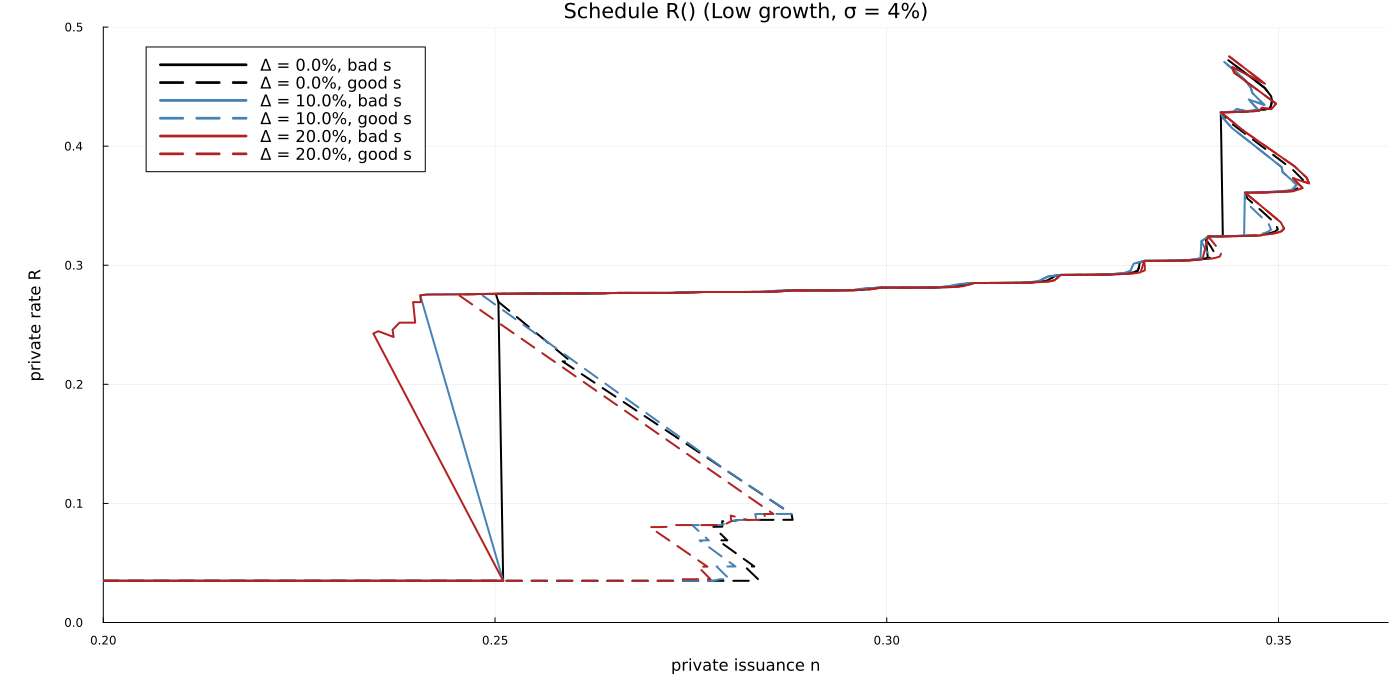

In [194]:
function plot_low_growth_schedule(data)
    p = plot(
        xlabel = "private issuance n",
        ylabel = "private rate R",
        title = "Schedule R() (Low growth, σ = 4%)",
        legend = :topleft,
        legendfontsize = 11,
        linewidth = 3,
        ylims = (0.0, 0.5),
        xlims = (0.2, 0.364),
        size = (1400, 700),
        left_margin = 12Plots.mm,
        bottom_margin = 10Plots.mm,
    )
    for d in data
        Δ_label = "Δ = $(round(100 * d.Δ, digits = 0))%"
        plot!(p, getfield.(d.bad, :n), getfield.(d.bad, :R) .- 1, color = d.color, linestyle = :solid, label = "$(Δ_label), bad s", linewidth = 2,)
        plot!(p, getfield.(d.good, :n), getfield.(d.good, :R) .- 1, color = d.color, linestyle = :dash, label = "$(Δ_label), good s", linewidth = 2,)
    end
    p
end

p_low_growth_schedule = plot_low_growth_schedule(schedule_plot_data)

low_growth_schedule_path = joinpath("result", "s_lolr_low_growth_Rn_eqm_lprime.png")
savefig(p_low_growth_schedule, low_growth_schedule_path)

(low_growth_schedule_path = low_growth_schedule_path, figure = p_low_growth_schedule)
display(p_low_growth_schedule)

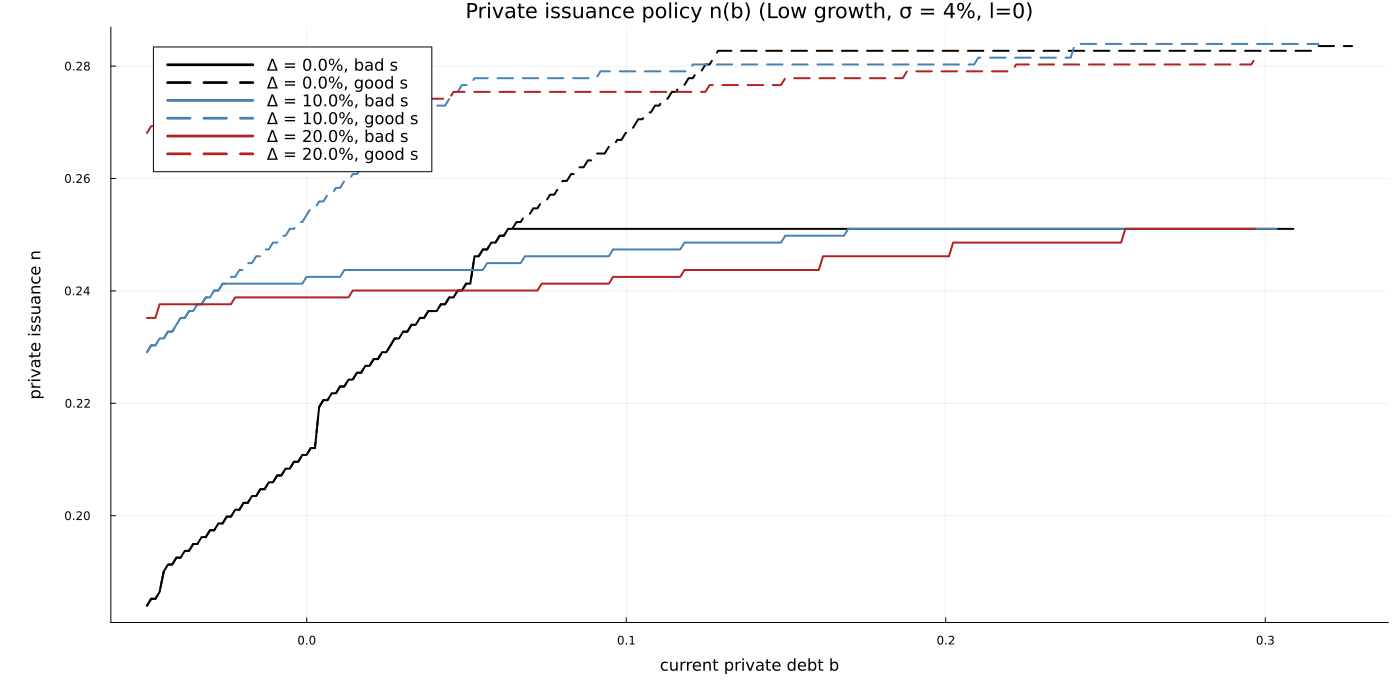

In [195]:
function build_low_growth_nb_policy_data(specs, cases)
    out = NamedTuple[]
    for spec in specs
        case_idx = findfirst(case -> case.key == spec.case_key, cases)
        @assert case_idx !== nothing "Case $(spec.case_key) not found"
        case = cases[case_idx]
        model = case.model
        sol = case.sol
        li_zero = findmin(abs.(model.l))[2]
        bad_bp = sol.b_policy_idx[:, li_zero, gi_low, s_bad, ei_mid]
        bad_lp = sol.l_policy_idx[:, li_zero, gi_low, s_bad, ei_mid]
        good_bp = sol.b_policy_idx[:, li_zero, gi_low, s_good, ei_mid]
        good_lp = sol.l_policy_idx[:, li_zero, gi_low, s_good, ei_mid]
        bad_n = [sol.n[bad_bp[bi], bad_lp[bi], gi_low, s_bad] for bi in 1:model.Nb]
        good_n = [sol.n[good_bp[bi], good_lp[bi], gi_low, s_good] for bi in 1:model.Nb]
        bad_repay = .!sol.d[:, li_zero, gi_low, s_bad, ei_mid]
        good_repay = .!sol.d[:, li_zero, gi_low, s_good, ei_mid]
        push!(out, (
            Δ = spec.Δ,
            color = spec.color,
            bad_b = model.b[bad_repay],
            bad_n = bad_n[bad_repay],
            good_b = model.b[good_repay],
            good_n = good_n[good_repay],
        ))
    end
    out
end

nb_policy_plot_data = build_low_growth_nb_policy_data(schedule_specs, lolr_moments_table_results.cases)

function plot_low_growth_nb(data)
    p = plot(
        xlabel = "current private debt b",
        ylabel = "private issuance n",
        title = "Private issuance policy n(b) (Low growth, σ = 4%, l=0)",
        legend = :topleft,
        legendfontsize = 11,
        linewidth = 3,
        left_margin = 12Plots.mm,
        bottom_margin = 10Plots.mm,
        size = (1400, 700),
    )
    for d in data
        Δ_label = "Δ = $(round(100 * d.Δ, digits = 0))%"
        plot!(p, d.bad_b, d.bad_n, color = d.color, linestyle = :solid, label = "$(Δ_label), bad s", linewidth = 2)
        plot!(p, d.good_b, d.good_n, color = d.color, linestyle = :dash, label = "$(Δ_label), good s", linewidth = 2)
    end
    p
end

p_low_growth_nb = plot_low_growth_nb(nb_policy_plot_data)

low_growth_nb_path = joinpath("result", "s_lolr_low_growth_nb_eqm_lprime.png")
savefig(p_low_growth_nb, low_growth_nb_path)

(low_growth_nb_path = low_growth_nb_path, figure = p_low_growth_nb)
display(p_low_growth_nb)


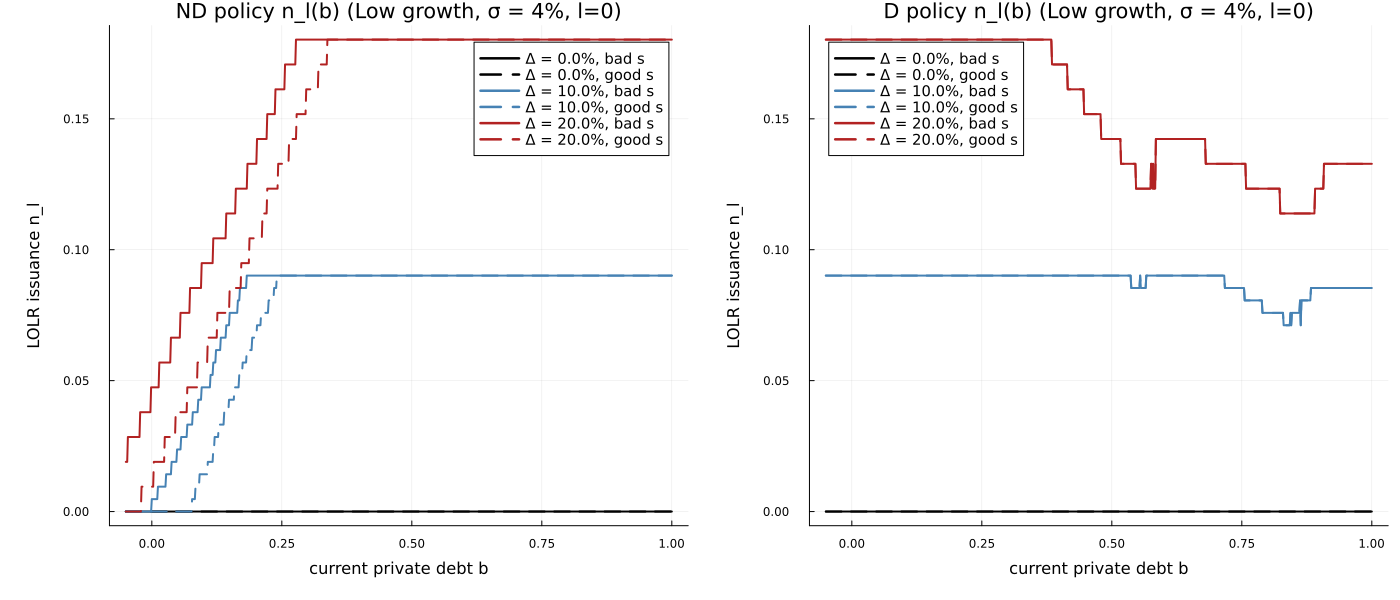

In [196]:
function build_low_growth_nl_policy_data(specs, cases)
    out = NamedTuple[]
    for spec in specs
        case_idx = findfirst(case -> case.key == spec.case_key, cases)
        @assert case_idx !== nothing "Case $(spec.case_key) not found"
        case = cases[case_idx]
        model = case.model
        sol = case.sol
        li_zero = findmin(abs.(model.l))[2]
        bad_lp_nd = sol.l_policy_idx[:, li_zero, gi_low, s_bad, ei_mid]
        good_lp_nd = sol.l_policy_idx[:, li_zero, gi_low, s_good, ei_mid]
        bad_lp_d = sol.l_policy_idx_d[:, li_zero, gi_low, s_bad, ei_mid]
        good_lp_d = sol.l_policy_idx_d[:, li_zero, gi_low, s_good, ei_mid]
        bad_nl_nd = (model.g[gi_low] .* model.l[bad_lp_nd]) ./ model.R_l_nd
        good_nl_nd = (model.g[gi_low] .* model.l[good_lp_nd]) ./ model.R_l_nd
        bad_nl_d = (model.g[gi_low] .* model.l[bad_lp_d]) ./ model.R_l_d
        good_nl_d = (model.g[gi_low] .* model.l[good_lp_d]) ./ model.R_l_d
        push!(out, (
            Δ = spec.Δ,
            color = spec.color,
            b = model.b,
            nd_bad_nl = bad_nl_nd,
            nd_good_nl = good_nl_nd,
            d_bad_nl = bad_nl_d,
            d_good_nl = good_nl_d,
        ))
    end
    out
end

nl_policy_plot_data = build_low_growth_nl_policy_data(schedule_specs, lolr_moments_table_results.cases)

function plot_low_growth_nl(data)
    p_nd = plot(
        xlabel = "current private debt b",
        ylabel = "LOLR issuance n_l",
        title = "ND policy n_l(b) (Low growth, σ = 4%, l=0)",
        legend = :topright,
        legendfontsize = 10,
        linewidth = 3,
        left_margin = 12Plots.mm,
        bottom_margin = 10Plots.mm,
        size = (700, 600),
    )
    p_d = plot(
        xlabel = "current private debt b",
        ylabel = "LOLR issuance n_l",
        title = "D policy n_l(b) (Low growth, σ = 4%, l=0)",
        legend = :topleft,
        legendfontsize = 10,
        linewidth = 3,
        left_margin = 12Plots.mm,
        bottom_margin = 10Plots.mm,
        size = (700, 600),
    )
    for d in data
        Δ_label = "Δ = $(round(100 * d.Δ, digits = 0))%"
        plot!(p_nd, d.b, d.nd_bad_nl, color = d.color, linestyle = :solid, label = "$(Δ_label), bad s", linewidth = 2)
        plot!(p_nd, d.b, d.nd_good_nl, color = d.color, linestyle = :dash, label = "$(Δ_label), good s", linewidth = 2)
        plot!(p_d, d.b, d.d_bad_nl, color = d.color, linestyle = :solid, label = "$(Δ_label), bad s", linewidth = 2)
        plot!(p_d, d.b, d.d_good_nl, color = d.color, linestyle = :dash, label = "$(Δ_label), good s", linewidth = 2)
    end
    plot(p_nd, p_d, layout = (1, 2), size = (1400, 600))
end

p_low_growth_nl = plot_low_growth_nl(nl_policy_plot_data)

low_growth_nl_path = joinpath("result", "s_lolr_low_growth_nl_policy.png")
savefig(p_low_growth_nl, low_growth_nl_path)

(low_growth_nl_path = low_growth_nl_path, figure = p_low_growth_nl)
display(p_low_growth_nl)


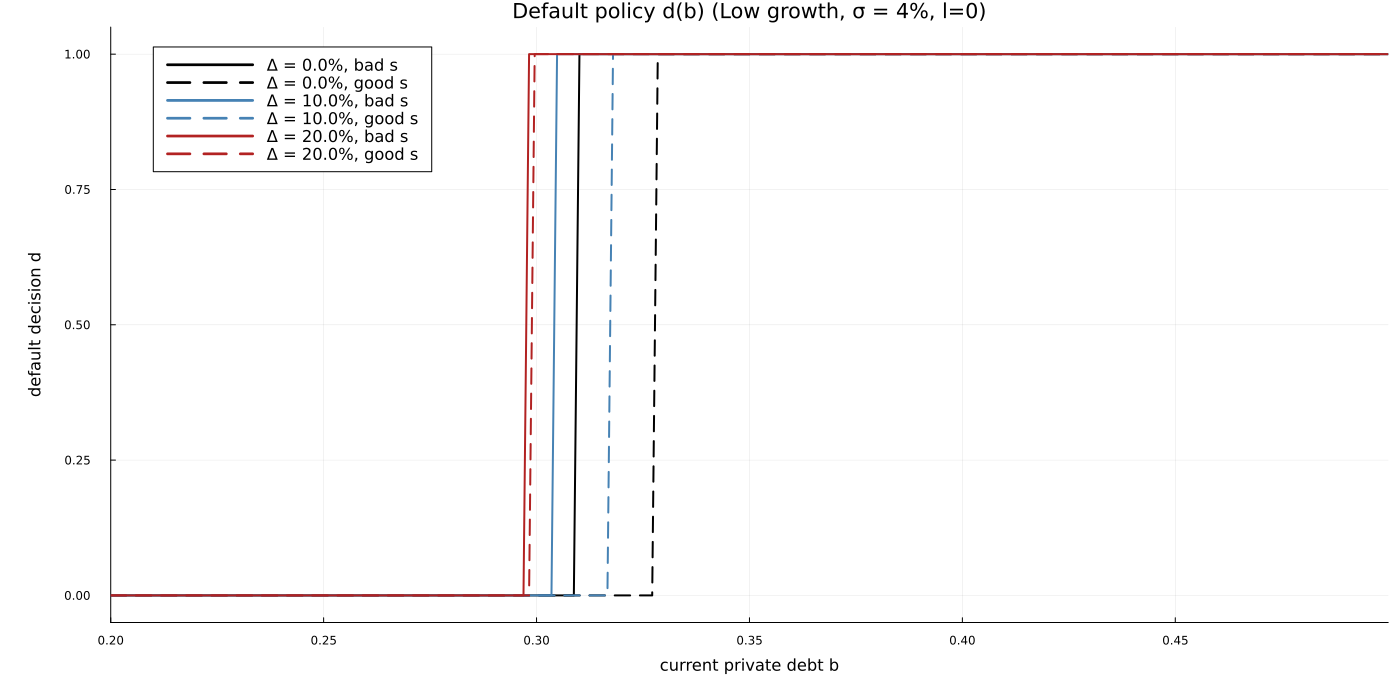

In [197]:
function build_low_growth_default_data(specs, cases)
    out = NamedTuple[]
    for spec in specs
        case_idx = findfirst(case -> case.key == spec.case_key, cases)
        @assert case_idx !== nothing "Case $(spec.case_key) not found"
        case = cases[case_idx]
        model = case.model
        sol = case.sol
        li_zero = findmin(abs.(model.l))[2]
        push!(out, (
            Δ = spec.Δ,
            color = spec.color,
            b = model.b,
            d_bad = Float64.(sol.d[:, li_zero, gi_low, s_bad, ei_mid]),
            d_good = Float64.(sol.d[:, li_zero, gi_low, s_good, ei_mid]),
        ))
    end
    out
end

default_plot_data = build_low_growth_default_data(schedule_specs, lolr_moments_table_results.cases)

function plot_low_growth_default(data)
    p = plot(
        xlabel = "current private debt b",
        ylabel = "default decision d",
        title = "Default policy d(b) (Low growth, σ = 4%, l=0)",
        legend = :topleft,
        legendfontsize = 11,
        linewidth = 3,
        left_margin = 12Plots.mm,
        bottom_margin = 10Plots.mm,
        ylims = (-0.05, 1.05),
        xlims = (0.2, 0.5),
        size = (1400, 700),
    )
    for d in data
        Δ_label = "Δ = $(round(100 * d.Δ, digits = 0))%"
        marker = d.Δ == 0.00 ? :square : (d.Δ == 0.10 ? :circle : :none)
        plot!(p, d.b, d.d_bad, color = d.color, linestyle = :solid, label = "$(Δ_label), bad s", linewidth = 2)
        plot!(p, d.b, d.d_good, color = d.color, linestyle = :dash, label = "$(Δ_label), good s", linewidth = 2)
    end
    p
end

p_low_growth_default = plot_low_growth_default(default_plot_data)

low_growth_default_path = joinpath("result", "s_lolr_low_growth_default_policy.png")
savefig(p_low_growth_default, low_growth_default_path)

(low_growth_default_path = low_growth_default_path, figure = p_low_growth_default)
display(p_low_growth_default)
